In [1]:
from transformers import GPT2LMHeadModel

[2025-05-10 11:52:21,675] [INFO] [real_accelerator.py:219:get_accelerator] Setting ds_accelerator to cuda (auto detect)


/data/projects/rosellm/.conda/compiler_compat/ld: cannot find -laio: 没有那个文件或目录
collect2: error: ld returned 1 exit status
/data/projects/rosellm/.conda/compiler_compat/ld: cannot find -laio: 没有那个文件或目录
collect2: error: ld returned 1 exit status


In [2]:
model_hf = GPT2LMHeadModel.from_pretrained("gpt2")
sd_hf = model_hf.state_dict()
for k, v in sd_hf.items():
    print(k, v.shape)

transformer.wte.weight torch.Size([50257, 768])
transformer.wpe.weight torch.Size([1024, 768])
transformer.h.0.ln_1.weight torch.Size([768])
transformer.h.0.ln_1.bias torch.Size([768])
transformer.h.0.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias torch.Size([2304])
transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias torch.Size([768])
transformer.h.0.ln_2.weight torch.Size([768])
transformer.h.0.ln_2.bias torch.Size([768])
transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias torch.Size([3072])
transformer.h.0.mlp.c_proj.weight torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias torch.Size([768])
transformer.h.1.ln_1.weight torch.Size([768])
transformer.h.1.ln_1.bias torch.Size([768])
transformer.h.1.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias torch.Size([2304])
transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias 

In [3]:
sd_hf["transformer.wpe.weight"].view(-1)[:20]

tensor([-0.0188, -0.1974,  0.0040,  0.0113,  0.0638, -0.1050,  0.0369, -0.1680,
        -0.0491, -0.0565, -0.0025,  0.0135, -0.0042,  0.0151,  0.0166, -0.1381,
        -0.0063, -0.0461,  0.0267, -0.2042])

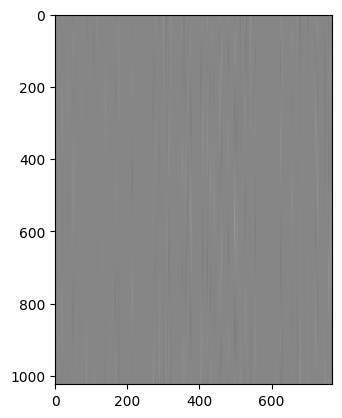

In [4]:
import matplotlib.pyplot as plt 
%matplotlib inline
plt.imshow(sd_hf["transformer.wpe.weight"], cmap="gray")

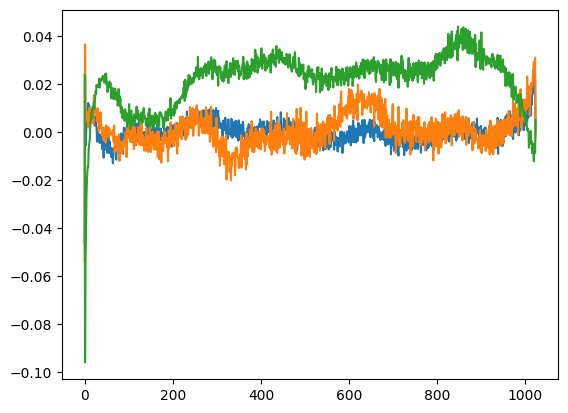

In [5]:
plt.plot(sd_hf["transformer.wpe.weight"][:, 150])
plt.plot(sd_hf["transformer.wpe.weight"][:, 200])
plt.plot(sd_hf["transformer.wpe.weight"][:, 250])

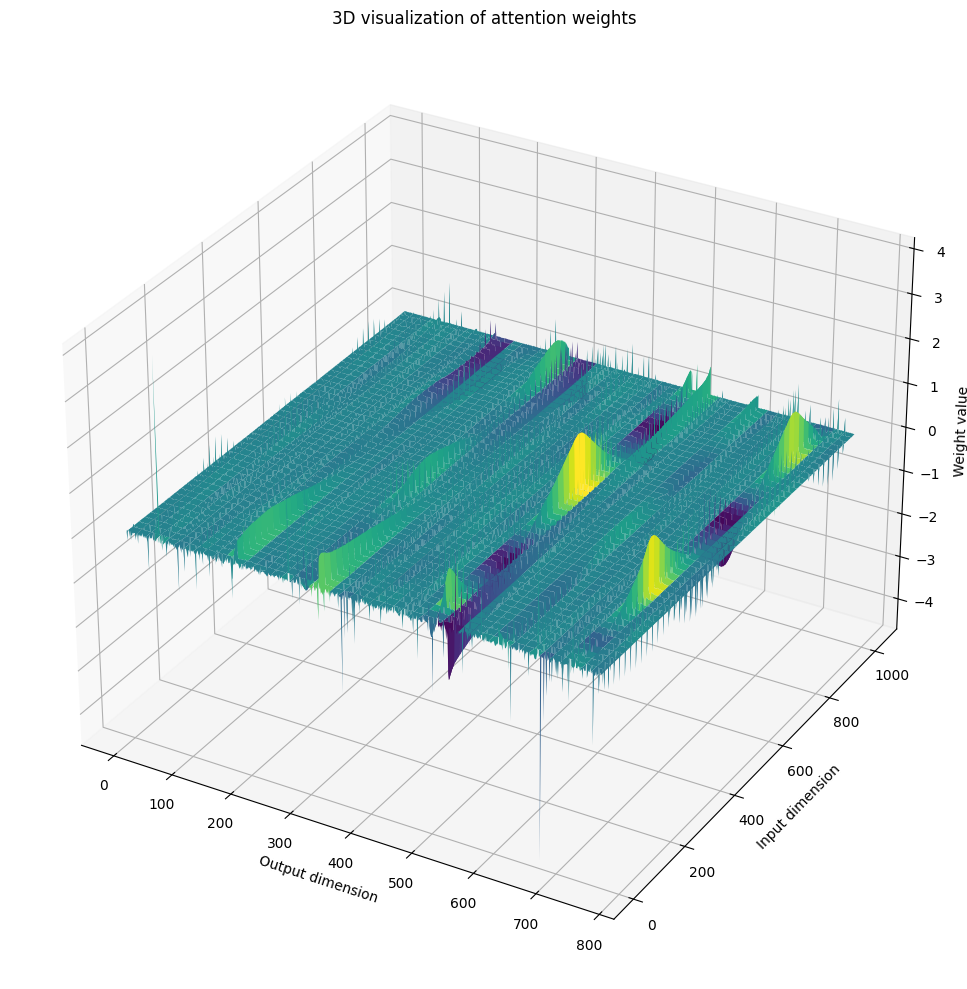

In [6]:
import numpy as np
fig = plt.figure(figsize=(12, 10), dpi=100)
ax = fig.add_subplot(111, projection='3d') # type: ignore
weight = sd_hf["transformer.wpe.weight"].numpy()
x, y = np.meshgrid(range(weight.shape[1]), range(weight.shape[0]))
ax.plot_surface(x, y, weight, cmap='viridis', edgecolor='none') # type: ignore
ax.set_xlabel('Output dimension')
ax.set_ylabel('Input dimension')
ax.set_zlabel('Weight value') # type: ignore
ax.set_title('3D visualization of attention weights')
plt.tight_layout()

Text(0.5, 0.92, '3D visualization of attention weights')

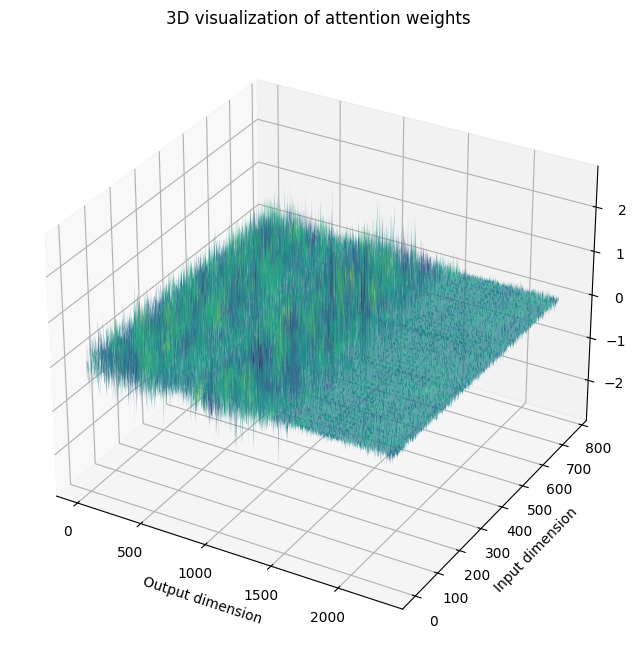

In [7]:
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d') # type: ignore

weight = sd_hf["transformer.h.0.attn.c_attn.weight"].numpy()
x, y = np.meshgrid(range(weight.shape[1]), range(weight.shape[0]))
ax.plot_surface(x, y, weight, cmap='viridis', edgecolor='none') # type: ignore

ax.set_xlabel('Output dimension')
ax.set_ylabel('Input dimension')
ax.set_zlabel('Weight value') # type: ignore
ax.set_title('3D visualization of attention weights')

In [8]:
print(weight.max(), weight.min(), weight.mean(), weight.std())

2.79563 -2.8436344 5.337546e-05 0.19961958


In [9]:
print(x)
print(y)

[[   0    1    2 ... 2301 2302 2303]
 [   0    1    2 ... 2301 2302 2303]
 [   0    1    2 ... 2301 2302 2303]
 ...
 [   0    1    2 ... 2301 2302 2303]
 [   0    1    2 ... 2301 2302 2303]
 [   0    1    2 ... 2301 2302 2303]]
[[  0   0   0 ...   0   0   0]
 [  1   1   1 ...   1   1   1]
 [  2   2   2 ...   2   2   2]
 ...
 [765 765 765 ... 765 765 765]
 [766 766 766 ... 766 766 766]
 [767 767 767 ... 767 767 767]]


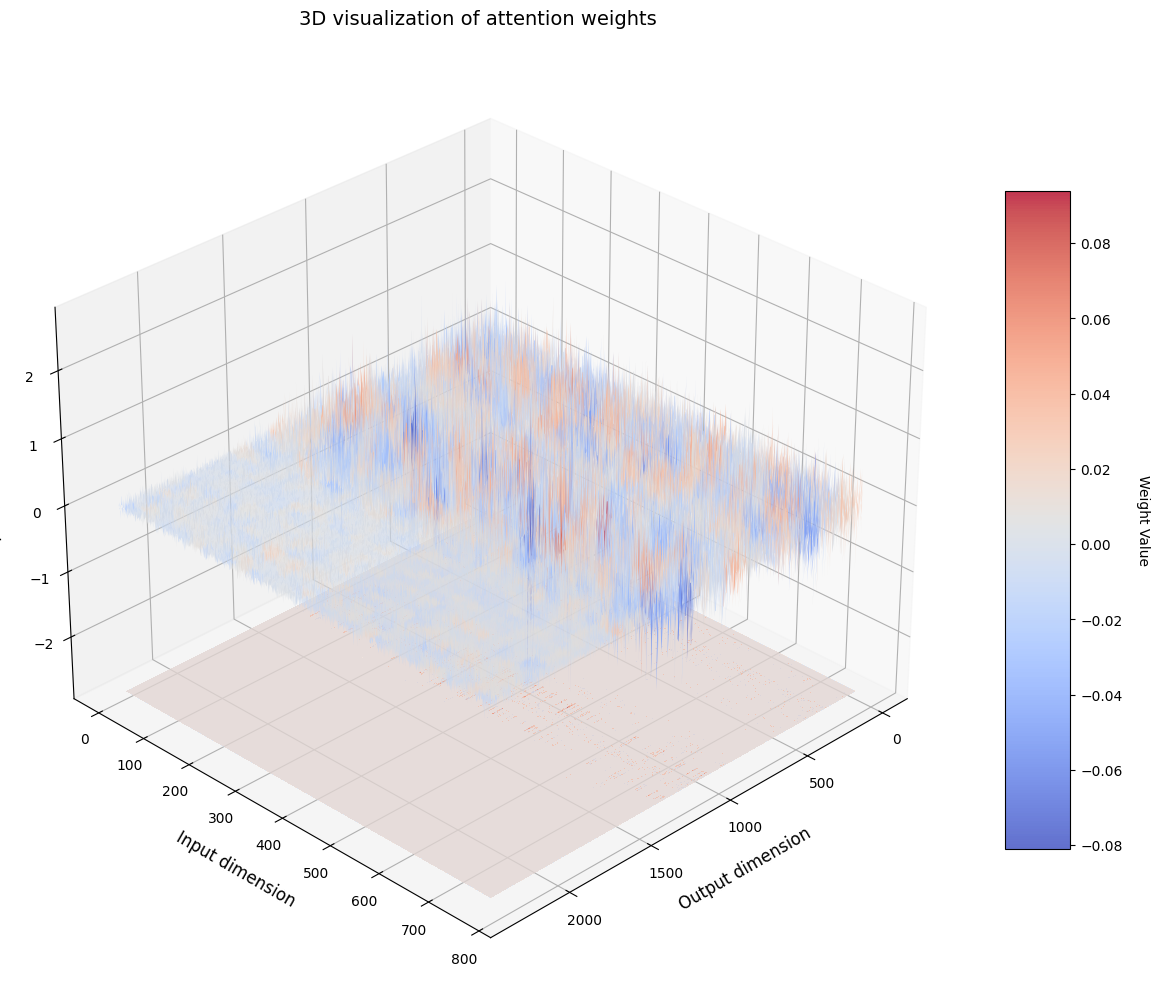

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

# 创建更高分辨率的图形
fig = plt.figure(figsize=(12, 10), dpi=100)
ax = fig.add_subplot(111, projection='3d') # type: ignore

weight = sd_hf["transformer.h.0.attn.c_attn.weight"].numpy()

# 可以通过采样减少数据点，使曲面更平滑（如果权重矩阵很大）
# 如果矩阵不大，可以不使用下面的采样代码
# sample_rate = 5
# weight = weight[::sample_rate, ::sample_rate]

x, y = np.meshgrid(range(weight.shape[1]), range(weight.shape[0]))

# 使用更好的颜色映射并添加光照效果
surf = ax.plot_surface(x, y, weight, cmap=cm.coolwarm, # type: ignore
                       linewidth=0, antialiased=True, # type: ignore
                       alpha=0.8)

# 添加颜色条解释权重值
cbar = fig.colorbar(surf, ax=ax, shrink=0.7, aspect=10)
cbar.set_label('Weight Value', rotation=270, labelpad=20)

# 添加底部轮廓以增强深度感
cset = ax.contourf(x, y, weight, zdir='z', offset=weight.min(), 
                   cmap=cm.coolwarm, alpha=0.5) # type: ignore

# 设置视角以更好地观察曲面
ax.view_init(elev=30, azim=45) # type: ignore

# 添加网格线
ax.grid(True, linestyle='-', linewidth=0.5, alpha=0.5)

# 精细化标签
ax.set_xlabel('Output dimension', fontsize=12, labelpad=10)
ax.set_ylabel('Input dimension', fontsize=12, labelpad=10)
ax.set_zlabel('Weight value', fontsize=12, labelpad=10) # type: ignore
ax.set_title('3D visualization of attention weights', fontsize=14, pad=20)

# 自定义坐标轴范围以突出重要区域
# ax.set_xlim(0, weight.shape[1])
# ax.set_ylim(0, weight.shape[0])
# ax.set_zlim(weight.min(), weight.max())

# 微调布局
plt.tight_layout()

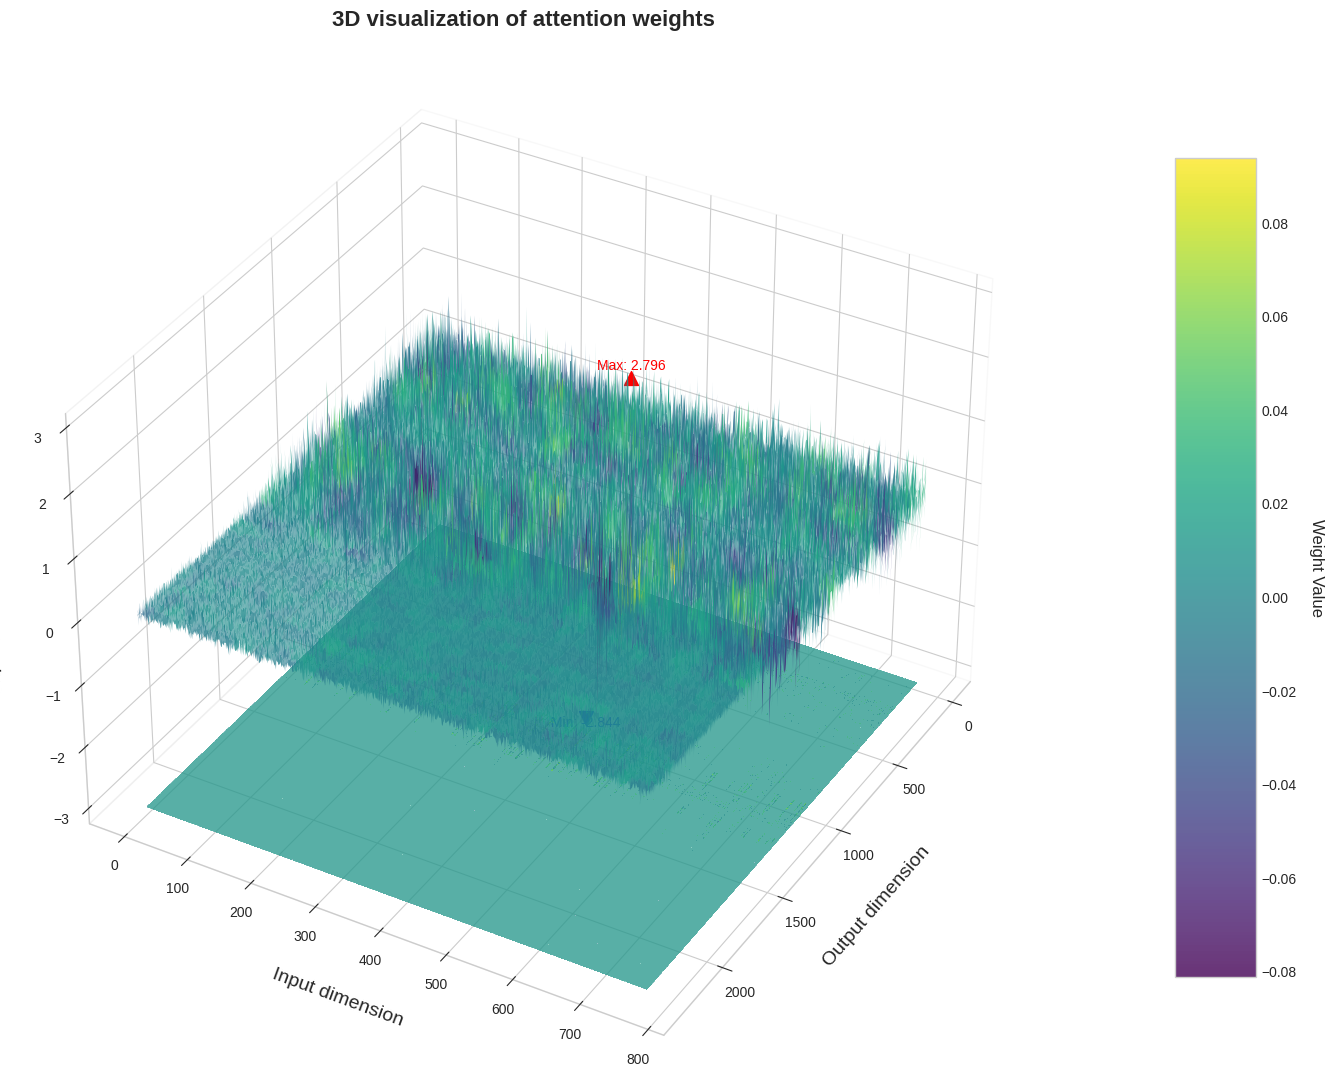

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

# 设置高质量风格
plt.style.use('seaborn-v0_8-whitegrid')

# 创建更高分辨率的图形
fig = plt.figure(figsize=(14, 12), dpi=100, facecolor='white')
ax = fig.add_subplot(111, projection='3d') # type: ignore

weight = sd_hf["transformer.h.0.attn.c_attn.weight"].numpy()

# 查找最大值和最小值及其位置
max_val = np.max(weight)
min_val = np.min(weight)
max_pos = np.unravel_index(np.argmax(weight), weight.shape)
min_pos = np.unravel_index(np.argmin(weight), weight.shape)

x, y = np.meshgrid(range(weight.shape[1]), range(weight.shape[0]))

# 设置白色或浅色背景
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

# 使用更美观的颜色映射
surf = ax.plot_surface(x, y, weight, cmap=cm.viridis, # type: ignore
                       linewidth=0, antialiased=True, # type: ignore
                       alpha=0.8)

# 标注最大值和最小值
ax.scatter([max_pos[1]], [max_pos[0]], [max_val], color='red', s=100, marker='^') # type: ignore
ax.scatter([min_pos[1]], [min_pos[0]], [min_val], color='blue', s=100, marker='v') # type: ignore

# 为最大/最小值添加文本标签
ax.text(max_pos[1], max_pos[0], max_val*1.05, # type: ignore
        f'Max: {max_val:.3f}', color='red', fontsize=10, ha='center') # type: ignore
ax.text(min_pos[1], min_pos[0], min_val*1.05, # type: ignore
        f'Min: {min_val:.3f}', color='blue', fontsize=10, ha='center') # type: ignore

# 添加改进的颜色条
cbar = fig.colorbar(surf, ax=ax, shrink=0.7, aspect=10, pad=0.1)
cbar.set_label('Weight Value', rotation=270, fontsize=12, labelpad=20)
cbar.ax.tick_params(labelsize=10)

# 添加底部轮廓
cset = ax.contourf(x, y, weight, zdir='z', offset=weight.min()*1.1, # type: ignore
                  cmap=cm.viridis, alpha=0.5) # type: ignore

# 设置优化视角
ax.view_init(elev=35, azim=30) # type: ignore

# 调整边框和网格线样式
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax.xaxis.pane.fill = False # type: ignore
ax.yaxis.pane.fill = False # type: ignore
ax.zaxis.pane.fill = False # type: ignore

# 精细化标签样式
ax.set_xlabel('Output dimension', fontsize=14, labelpad=15)
ax.set_ylabel('Input dimension', fontsize=14, labelpad=15)
ax.set_zlabel('Weight value', fontsize=14, labelpad=15) # type: ignore
ax.set_title('3D visualization of attention weights', fontsize=16, pad=20, fontweight='bold')

# 添加边界框
for spine in ax.spines.values(): # type: ignore
    spine.set_edgecolor('0.8')

# 微调布局
plt.tight_layout()

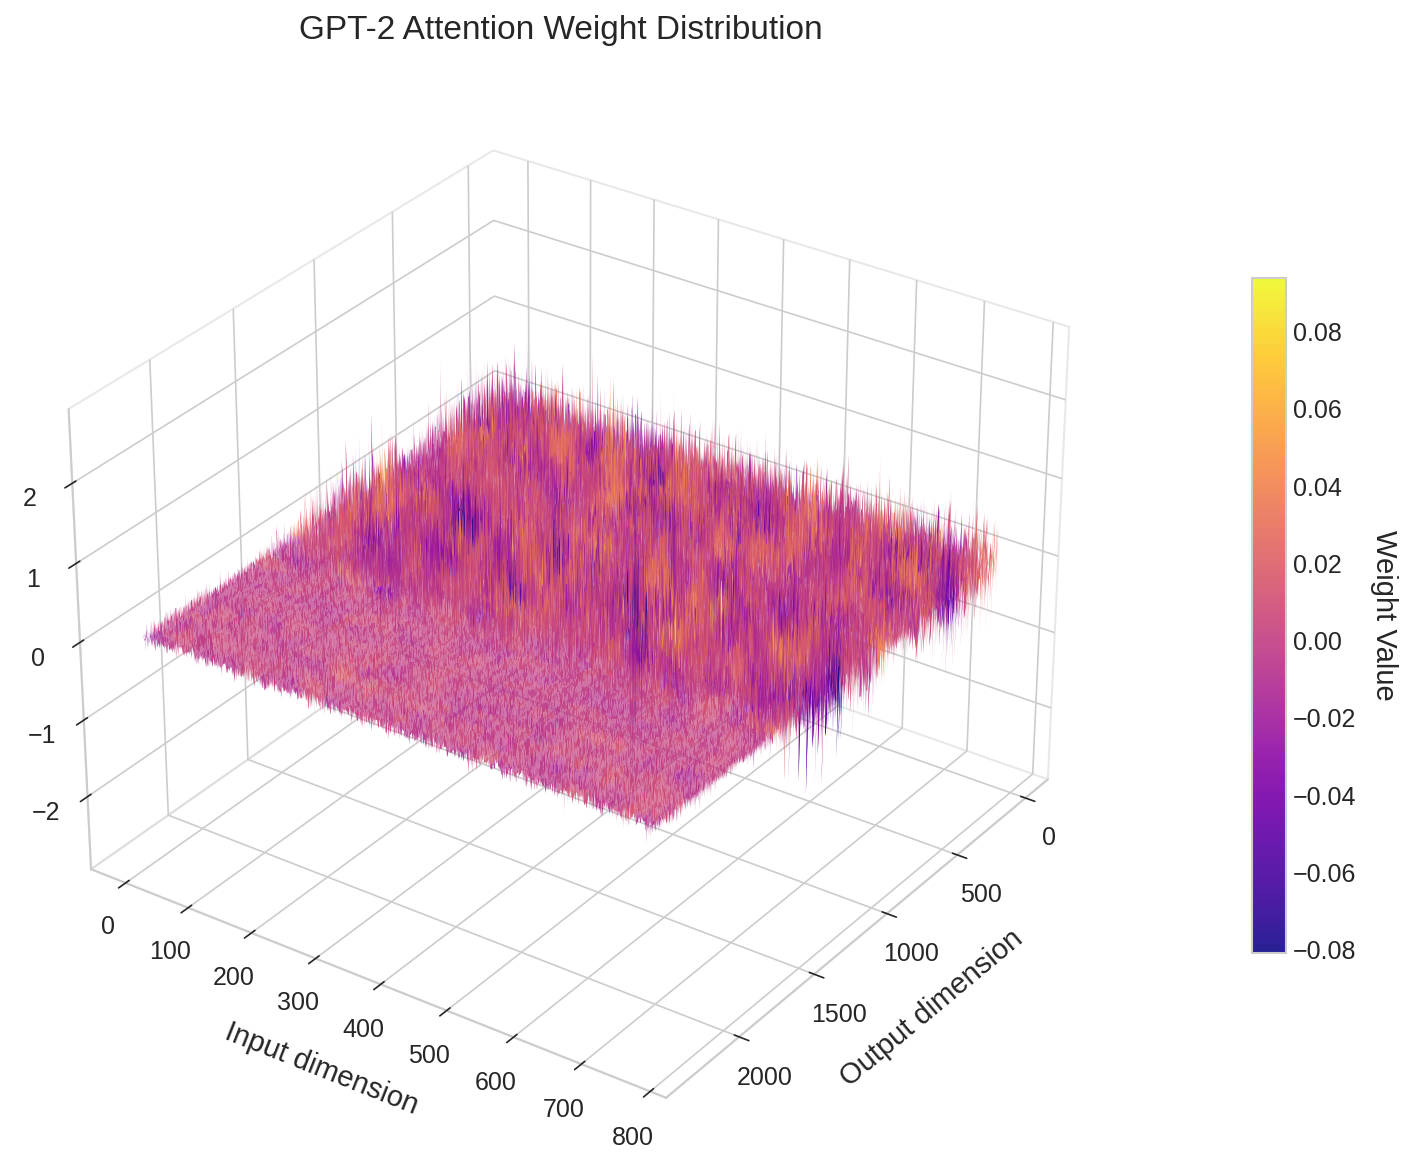

In [12]:
import numpy as np
import matplotlib.pyplot as plt
# from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
# import matplotlib as mpl

# 设置学术风格的字体和样式
plt.rcParams.update({
    # "text.usetex": True,
    # 'font.family': 'serif',
    # 'font.serif': ['Computer Modern Roman'],
    # 'mathtext.fontset': 'cm',
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12
})

# 创建图形
fig = plt.figure(figsize=(10, 8), dpi=150, facecolor='white')
ax = fig.add_subplot(111, projection='3d') # type: ignore

weight = sd_hf["transformer.h.0.attn.c_attn.weight"].numpy()

# 查找最大值和最小值及其位置
max_val = np.max(weight)
min_val = np.min(weight)
max_pos = np.unravel_index(np.argmax(weight), weight.shape)
min_pos = np.unravel_index(np.argmin(weight), weight.shape)

x, y = np.meshgrid(range(weight.shape[1]), range(weight.shape[0]))

# 设置纯白色背景
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

# 使用学术风格的配色方案
surf = ax.plot_surface(x, y, weight, cmap='plasma', # type: ignore
                      linewidth=0, antialiased=True, # type: ignore
                      alpha=0.9)

# 标注最大值和最小值（使用更清晰的标记）
# ax.scatter([max_pos[1]], [max_pos[0]], [max_val], color='#e41a1c', s=80, marker='o', # type: ignore
#           edgecolor='black', linewidth=1)
# ax.scatter([min_pos[1]], [min_pos[0]], [min_val], color='#377eb8', s=80, marker='o', # type: ignore
#           edgecolor='black', linewidth=1)

# 为最大/最小值添加简洁标签
# ax.text(max_pos[1], max_pos[0], max_val*1.05, # type: ignore
#        f'Max: {max_val:.2f}', color='black', fontsize=12, ha='center', 
#        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))
# ax.text(min_pos[1], min_pos[0], min_val*1.05, # type: ignore
#        f'Min: {min_val:.2f}', color='black', fontsize=12, ha='center',
#        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))

# 添加符合学术风格的颜色条
cbar = fig.colorbar(surf, ax=ax, shrink=0.6, aspect=20, pad=0.1)
cbar.set_label('Weight Value', rotation=270, fontsize=14, labelpad=20)
cbar.ax.tick_params(labelsize=12)

# 设置专业视角
ax.view_init(elev=30, azim=35) # type: ignore

# 添加适当的网格线
ax.grid(True, linestyle='-', linewidth=0.3, alpha=0.3, color='gray')

# 设置半透明的轴平面
ax.xaxis.pane.fill = False # type: ignore
ax.yaxis.pane.fill = False # type: ignore
ax.zaxis.pane.fill = False # type: ignore
ax.xaxis.pane.set_edgecolor('lightgray') # type: ignore
ax.yaxis.pane.set_edgecolor('lightgray') # type: ignore
ax.zaxis.pane.set_edgecolor('lightgray') # type: ignore

# 标签和标题
ax.set_xlabel('Output dimension', fontsize=14, labelpad=10)
ax.set_ylabel('Input dimension', fontsize=14, labelpad=10)
ax.set_zlabel('Weight value', fontsize=14, labelpad=10) # type: ignore
ax.set_title('GPT-2 Attention Weight Distribution', fontsize=16, pad=15)

# 微调布局
plt.tight_layout()

In [23]:
from transformers import pipeline, set_seed
generator = pipeline('text-generation', model='gpt2')
set_seed(42)
generator("Hello, I'm a language model,", max_length=30, num_return_sequences=5)

Device set to use cuda:0
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


[{'generated_text': 'Hello, I\'m a language model, so you can\'t define something in any other language. Let me introduce another topic:\n\nThe name "'},
 {'generated_text': "Hello, I'm a language model, you know.\n\nThat's right… I have a lot of friends who don't know what I do"},
 {'generated_text': 'Hello, I\'m a language model, not an interpreter. So I know what you\'re thinking: "I understand better".\n\nThis is true'},
 {'generated_text': 'Hello, I\'m a language model, so I don\'t know what I can do with this code and why nobody wants to use it." "Why'},
 {'generated_text': "Hello, I'm a language model, so I'm a good deal better at being an abstract language model.\n\nBut…why are they so"}]

In [27]:
# !wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
with open("input.txt", "r") as f:
    text = f.read()

print(text[:100])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You


In [28]:
import tiktoken
enc = tiktoken.get_encoding("gpt2")
tokens = enc.encode(text)
print(len(tokens))
print(tokens[:24])

338025
[5962, 22307, 25, 198, 8421, 356, 5120, 597, 2252, 11, 3285, 502, 2740, 13, 198, 198, 3237, 25, 198, 5248, 461, 11, 2740, 13]


In [30]:
import torch
buf = torch.tensor(tokens[:24 + 1])
x = buf[:-1].view(4, 6) 
y = buf[1:].view(4, 6)
print(x)
print(y)

tensor([[ 5962, 22307,    25,   198,  8421,   356],
        [ 5120,   597,  2252,    11,  3285,   502],
        [ 2740,    13,   198,   198,  3237,    25],
        [  198,  5248,   461,    11,  2740,    13]])
tensor([[22307,    25,   198,  8421,   356,  5120],
        [  597,  2252,    11,  3285,   502,  2740],
        [   13,   198,   198,  3237,    25,   198],
        [ 5248,   461,    11,  2740,    13,   198]])


In [31]:
print(sd_hf["lm_head.weight"].shape)
print(sd_hf["transformer.wte.weight"].shape)

torch.Size([50257, 768])
torch.Size([50257, 768])


In [32]:
(sd_hf["lm_head.weight"] == sd_hf["transformer.wte.weight"]).all()

tensor(True)

In [33]:
print(sd_hf["lm_head.weight"].data_ptr())
print(sd_hf["transformer.wte.weight"].data_ptr())

137022670811091
137022670811091


In [37]:
x = torch.zeros(768)
n = 100
for i in range(n):
    x += n**-0.5 * torch.randn(768)
    # x += torch.randn(768)
    print(i, x.std())
print(x.std())

0 tensor(0.1026)
1 tensor(0.1466)
2 tensor(0.1760)
3 tensor(0.1983)
4 tensor(0.2221)
5 tensor(0.2418)
6 tensor(0.2627)
7 tensor(0.2819)
8 tensor(0.2991)
9 tensor(0.3133)
10 tensor(0.3270)
11 tensor(0.3404)
12 tensor(0.3553)
13 tensor(0.3692)
14 tensor(0.3765)
15 tensor(0.3982)
16 tensor(0.4077)
17 tensor(0.4240)
18 tensor(0.4287)
19 tensor(0.4451)
20 tensor(0.4541)
21 tensor(0.4621)
22 tensor(0.4698)
23 tensor(0.4796)
24 tensor(0.4953)
25 tensor(0.5061)
26 tensor(0.5166)
27 tensor(0.5269)
28 tensor(0.5314)
29 tensor(0.5394)
30 tensor(0.5385)
31 tensor(0.5473)
32 tensor(0.5531)
33 tensor(0.5644)
34 tensor(0.5718)
35 tensor(0.5791)
36 tensor(0.5902)
37 tensor(0.5954)
38 tensor(0.5984)
39 tensor(0.6103)
40 tensor(0.6208)
41 tensor(0.6293)
42 tensor(0.6458)
43 tensor(0.6496)
44 tensor(0.6604)
45 tensor(0.6669)
46 tensor(0.6700)
47 tensor(0.6806)
48 tensor(0.6832)
49 tensor(0.6918)
50 tensor(0.6949)
51 tensor(0.6947)
52 tensor(0.7047)
53 tensor(0.7125)
54 tensor(0.7245)
55 tensor(0.7381)
56